# audEERING emotion-distance analysis

This notebook calculates sentence-matched emotion distances for the ProMoNet and Praat edits. Distances use the model's raw arousal, dominance, and valence scores:

`target gain = baseline-to-target distance - edited-to-target distance`

Positive gain means an edit moved toward its matched natural happy or sad recording. The bootstrap intervals quantify sentence-level uncertainty for speaker 47 only; they do not support cross-speaker generalization.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import display

ADV_COLUMNS = ["arousal", "dominance", "valence"]
BOOTSTRAP_ITERATIONS = 10_000
RANDOM_SEED = 20_260_823
EXPECTED_SCORE_ROWS = 398
EXPECTED_EDIT_ROWS = 198

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "audio").is_dir() and (candidate / "outputs").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find the ProMoNet project root above {start}"
    )

PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "audEERING"
SCORES_PATH = OUTPUT_DIR / "audeering_scores.csv"
PER_ITEM_PATH = OUTPUT_DIR / "emotion_distance_per_item.csv"
SUMMARY_PATH = OUTPUT_DIR / "emotion_distance_summary.csv"
FIGURE_PNG_PATH = OUTPUT_DIR / "emotion_validation_figure.png"
FIGURE_PDF_PATH = OUTPUT_DIR / "emotion_validation_figure.pdf"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def write_csv_atomic(frame: pd.DataFrame, path: Path) -> None:
    temporary = path.with_name(path.name + ".tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input scores: {SCORES_PATH}")
print(f"Bootstrap iterations: {BOOTSTRAP_ITERATIONS:,}")

Project root: C:\projects\ProMoNet
Input scores: C:\projects\ProMoNet\outputs\audEERING\audeering_scores.csv
Bootstrap iterations: 10,000


## 1. Load and validate audEERING scores

The analysis requires one successful row per audio file and the exact current group structure. It fails early rather than silently dropping or mispairing observations.

In [2]:
if not SCORES_PATH.is_file():
    raise FileNotFoundError(f"Missing audEERING score table: {SCORES_PATH}")

scores = pd.read_csv(
    SCORES_PATH,
    dtype={"speaker_id": "string", "sentence_id": "string"},
)
required_columns = {
    "relative_path", "system", "condition", "speaker_id",
    "sentence_id", "target_emotion", "status", *ADV_COLUMNS,
}
missing_columns = sorted(required_columns - set(scores.columns))
if missing_columns:
    raise ValueError(f"Score table is missing columns: {missing_columns}")
if len(scores) != EXPECTED_SCORE_ROWS:
    raise ValueError(f"Expected 398 score rows; found {len(scores)}")
if scores["relative_path"].duplicated().any():
    duplicates = scores.loc[
        scores["relative_path"].duplicated(keep=False), "relative_path"
    ]
    raise ValueError("Duplicate score paths:\n" + duplicates.to_string(index=False))
if not scores["status"].eq("success").all():
    failed = scores.loc[
        ~scores["status"].eq("success"), ["relative_path", "status"]
    ]
    raise ValueError("Unsuccessful score rows:\n" + failed.to_string(index=False))
if not np.isfinite(scores[ADV_COLUMNS].to_numpy(dtype=float)).all():
    raise ValueError("Arousal, dominance, and valence must all be finite")
if not set(scores["target_emotion"]).issubset({"hap", "neu", "sad"}):
    unexpected = sorted(set(scores["target_emotion"]) - {"hap", "neu", "sad"})
    raise ValueError(f"Unexpected target emotions: {unexpected}")

EXPECTED_GROUP_COUNTS = {
    ("natural", "natural", "hap"): 50,
    ("natural", "natural", "neu"): 50,
    ("natural", "natural", "sad"): 50,
    ("promonet", "edit", "hap"): 49,
    ("promonet", "edit", "sad"): 50,
    ("promonet", "reconstruction", "neu"): 50,
    ("praat", "edit", "hap"): 49,
    ("praat", "edit", "sad"): 50,
}
group_counts = scores.groupby(
    ["system", "condition", "target_emotion"]
).size().to_dict()
if group_counts != EXPECTED_GROUP_COUNTS:
    raise ValueError(
        f"Unexpected condition counts. Expected {EXPECTED_GROUP_COUNTS}; "
        f"found {group_counts}"
    )
display(
    scores.groupby(["system", "condition", "target_emotion"])
    .size().rename("recordings").to_frame()
)
print("Input validation passed: 398 unique successful score rows.")

recordings
system   condition      target_emotion            
natural  natural        hap                     50
                        neu                     50
                        sad                     50
praat    edit           hap                     49
                        sad                     50
promonet edit           hap                     49
                        sad                     50
         reconstruction neu                     50

Input validation passed: 398 unique successful score rows.


## 2. Build sentence-matched distances

For ProMoNet, the baseline is its neutral reconstruction. For Praat, the baseline is the original neutral recording. Both systems are evaluated against the same sentence's natural emotional target. All three ADV dimensions are included in the Euclidean distances.

In [3]:
def require_unique_lookup(
    frame: pd.DataFrame, index_columns: list[str], label: str
) -> pd.DataFrame:
    duplicates = frame.duplicated(index_columns, keep=False)
    if duplicates.any():
        raise ValueError(
            f"Duplicate {label} lookup keys:\n"
            + frame.loc[duplicates, index_columns + ["relative_path"]].to_string(index=False)
        )
    return frame.set_index(index_columns, verify_integrity=True)

natural = scores[scores["system"].eq("natural")].copy()
natural_lookup = require_unique_lookup(
    natural, ["speaker_id", "sentence_id", "target_emotion"], "natural"
)
reconstructions = scores[
    scores["system"].eq("promonet")
    & scores["condition"].eq("reconstruction")
].copy()
reconstruction_lookup = require_unique_lookup(
    reconstructions, ["speaker_id", "sentence_id"], "reconstruction"
)
edits = scores[
    scores["system"].isin(["promonet", "praat"])
    & scores["condition"].eq("edit")
].copy()

per_item_rows: list[dict[str, object]] = []
for _, edited in edits.iterrows():
    speaker = edited["speaker_id"]
    sentence = edited["sentence_id"]
    target_emotion = edited["target_emotion"]
    target_key = (speaker, sentence, target_emotion)
    if target_key not in natural_lookup.index:
        raise KeyError(f"Missing matched natural target: {target_key}")
    natural_target = natural_lookup.loc[target_key]

    if edited["system"] == "promonet":
        baseline_key = (speaker, sentence)
        if baseline_key not in reconstruction_lookup.index:
            raise KeyError(f"Missing ProMoNet reconstruction: {baseline_key}")
        baseline = reconstruction_lookup.loc[baseline_key]
        baseline_type = "promonet_reconstruction"
    else:
        baseline_key = (speaker, sentence, "neu")
        if baseline_key not in natural_lookup.index:
            raise KeyError(f"Missing natural neutral baseline: {baseline_key}")
        baseline = natural_lookup.loc[baseline_key]
        baseline_type = "natural_neutral"

    baseline_scores = baseline[ADV_COLUMNS].to_numpy(dtype=float)
    edited_scores = edited[ADV_COLUMNS].to_numpy(dtype=float)
    target_scores = natural_target[ADV_COLUMNS].to_numpy(dtype=float)
    baseline_distance = float(np.linalg.norm(baseline_scores - target_scores))
    edited_distance = float(np.linalg.norm(edited_scores - target_scores))
    target_gain = baseline_distance - edited_distance

    row = {
        "speaker_id": speaker,
        "sentence_id": sentence,
        "system": edited["system"],
        "target_emotion": target_emotion,
        "baseline_type": baseline_type,
        "baseline_relative_path": baseline["relative_path"],
        "edited_relative_path": edited["relative_path"],
        "natural_target_relative_path": natural_target["relative_path"],
        "baseline_target_distance": baseline_distance,
        "edited_target_distance": edited_distance,
        "target_gain": target_gain,
        "positive_gain": bool(target_gain > 0.0),
    }
    for dimension in ADV_COLUMNS:
        row[f"baseline_{dimension}"] = float(baseline[dimension])
        row[f"edited_{dimension}"] = float(edited[dimension])
        row[f"natural_target_{dimension}"] = float(natural_target[dimension])
    per_item_rows.append(row)

per_item = pd.DataFrame(per_item_rows).sort_values(
    ["target_emotion", "system", "speaker_id", "sentence_id"]
).reset_index(drop=True)
if len(per_item) != EXPECTED_EDIT_ROWS:
    raise AssertionError(f"Expected 198 edit rows; found {len(per_item)}")
edit_counts = per_item.groupby(["system", "target_emotion"]).size().to_dict()
expected_edit_counts = {
    ("promonet", "hap"): 49, ("promonet", "sad"): 50,
    ("praat", "hap"): 49, ("praat", "sad"): 50,
}
if edit_counts != expected_edit_counts:
    raise AssertionError(f"Unexpected edit counts: {edit_counts}")
for system in ["promonet", "praat"]:
    happy_ids = set(
        per_item.loc[
            per_item["system"].eq(system)
            & per_item["target_emotion"].eq("hap"), "sentence_id"
        ]
    )
    if "39" in happy_ids:
        raise AssertionError(f"Sentence 39 must remain excluded from {system} happy edits")
write_csv_atomic(per_item, PER_ITEM_PATH)
display(per_item.head(10))
print(f"Saved {len(per_item)} sentence-matched edit rows to {PER_ITEM_PATH}")

C:\Users\JunZ\AppData\Local\Temp\ipykernel_31788\3008623041.py:10: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  return frame.set_index(index_columns, verify_integrity=True)
C:\Users\JunZ\AppData\Local\Temp\ipykernel_31788\3008623041.py:10: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  return frame.set_index(index_columns, verify_integrity=True)


,speaker_id,sentence_id,system,target_emotion,baseline_type,baseline_relative_path,edited_relative_path,natural_target_relative_path,baseline_target_distance,edited_target_distance,...,positive_gain,baseline_arousal,edited_arousal,natural_target_arousal,baseline_dominance,edited_dominance,natural_target_dominance,baseline_valence,edited_valence,natural_target_valence
0,47,01,praat,hap,natural_neutral,audio/47_01_neu_f.wav,outputs/praat_pipeline/speaker_47/47_01_neu_fr...,audio/47_01_hap_f.wav,0.161499,0.105065,...,True,0.371326,0.413773,0.495599,0.467857,0.472937,0.537245,0.396019,0.334119,0.319708
1,47,02,praat,hap,natural_neutral,audio/47_02_neu_f.wav,outputs/praat_pipeline/speaker_47/47_02_neu_fr...,audio/47_02_hap_f.wav,0.216652,0.016128,...,True,0.380592,0.549339,0.554099,0.470468,0.591949,0.592029,0.423995,0.484754,0.469345
2,47,03,praat,hap,natural_neutral,audio/47_03_neu_f.wav,outputs/praat_pipeline/speaker_47/47_03_neu_fr...,audio/47_03_hap_f.wav,0.092340,0.104638,...,False,0.418445,0.456961,0.499588,0.484644,0.512080,0.526496,0.623548,0.515259,0.609727
3,47,04,praat,hap,natural_neutral,audio/47_04_neu_f.wav,outputs/praat_pipeline/speaker_47/47_04_neu_fr...,audio/47_04_hap_f.wav,0.150630,0.093598,...,True,0.426024,0.480587,0.549471,0.539386,0.577331,0.620091,0.376407,0.360247,0.407016
4,47,05,praat,hap,natural_neutral,audio/47_05_neu_f.wav,outputs/praat_pipeline/speaker_47/47_05_neu_fr...,audio/47_05_hap_f.wav,0.269722,0.104277,...,True,0.396912,0.536546,0.620978,0.493275,0.582517,0.638520,0.395358,0.408739,0.433410
5,47,06,praat,hap,natural_neutral,audio/47_06_neu_f.wav,outputs/praat_pipeline/speaker_47/47_06_neu_fr...,audio/47_06_hap_f.wav,0.279793,0.086370,...,True,0.419744,0.590976,0.653285,0.489656,0.595704,0.643651,0.447514,0.417011,0.452764
6,47,07,praat,hap,natural_neutral,audio/47_07_neu_f.wav,outputs/praat_pipeline/speaker_47/47_07_neu_fr...,audio/47_07_hap_f.wav,0.189283,0.197231,...,False,0.392484,0.495361,0.500524,0.516382,0.580331,0.567052,0.584705,0.634492,0.437776
7,47,08,praat,hap,natural_neutral,audio/47_08_neu_f.wav,outputs/praat_pipeline/speaker_47/47_08_neu_fr...,audio/47_08_hap_f.wav,0.188600,0.094970,...,True,0.409907,0.488147,0.560766,0.488709,0.532738,0.589423,0.349395,0.320817,0.297742
8,47,09,praat,hap,natural_neutral,audio/47_09_neu_f.wav,outputs/praat_pipeline/speaker_47/47_09_neu_fr...,audio/47_09_hap_f.wav,0.125153,0.068102,...,True,0.377001,0.442455,0.488358,0.470903,0.487089,0.527976,0.468367,0.441427,0.470736
9,47,10,praat,hap,natural_neutral,audio/47_10_neu_f.wav,outputs/praat_pipeline/speaker_47/47_10_neu_fr...,audio/47_10_hap_f.wav,0.336530,0.153265,...,True,0.357388,0.509027,0.629005,0.470574,0.583715,0.669261,0.324597,0.282727,0.324885


Saved 198 sentence-matched edit rows to C:\projects\ProMoNet\outputs\audEERING\emotion_distance_per_item.csv


## 3. Summarize gain and bootstrap uncertainty

Each interval is the percentile interval from 10,000 bootstrap samples of sentences within one system and target emotion.

In [4]:
def bootstrap_median_ci(
    values: np.ndarray, rng: np.random.Generator
) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or values.size == 0:
        raise ValueError("Bootstrap input must be a nonempty one-dimensional array")
    indices = rng.integers(
        0, values.size, size=(BOOTSTRAP_ITERATIONS, values.size)
    )
    bootstrap_medians = np.median(values[indices], axis=1)
    low, high = np.percentile(bootstrap_medians, [2.5, 97.5])
    return float(low), float(high)

GROUP_ORDER = [
    ("promonet", "hap"),
    ("praat", "hap"),
    ("promonet", "sad"),
    ("praat", "sad"),
]
rng = np.random.default_rng(RANDOM_SEED)
summary_rows: list[dict[str, object]] = []
for system, target_emotion in GROUP_ORDER:
    group = per_item[
        per_item["system"].eq(system)
        & per_item["target_emotion"].eq(target_emotion)
    ]
    gains = group["target_gain"].to_numpy(dtype=float)
    ci_low, ci_high = bootstrap_median_ci(gains, rng)
    summary_rows.append(
        {
            "system": system,
            "target_emotion": target_emotion,
            "n": int(len(group)),
            "median_target_gain": float(np.median(gains)),
            "bootstrap_ci_low": ci_low,
            "bootstrap_ci_high": ci_high,
            "positive_gain_pct": float(100.0 * np.mean(gains > 0.0)),
            "median_target_distance": float(
                group["edited_target_distance"].median()
            ),
        }
    )

summary = pd.DataFrame(summary_rows)
if len(summary) != 4:
    raise AssertionError(f"Expected four summary rows; found {len(summary)}")
expected_n = {"hap": 49, "sad": 50}
for row in summary.itertuples(index=False):
    if row.n != expected_n[row.target_emotion]:
        raise AssertionError(
            f"Unexpected N for {row.system}/{row.target_emotion}: {row.n}"
        )

EXPECTED_MEDIANS = {
    ("promonet", "hap"): 0.1283,
    ("promonet", "sad"): -0.0022,
    ("praat", "hap"): 0.1077,
    ("praat", "sad"): -0.0105,
}
for row in summary.itertuples(index=False):
    expected = EXPECTED_MEDIANS[(row.system, row.target_emotion)]
    if not np.isclose(row.median_target_gain, expected, atol=0.002):
        raise AssertionError(
            f"Median gain regression check failed for {row.system}/"
            f"{row.target_emotion}: {row.median_target_gain:.4f} vs {expected:.4f}"
        )

write_csv_atomic(summary, SUMMARY_PATH)
summary_display = summary.copy()
summary_display["system"] = summary_display["system"].map(
    {"promonet": "ProMoNet", "praat": "Praat"}
)
summary_display["target_emotion"] = summary_display["target_emotion"].map(
    {"hap": "Happy", "sad": "Sad"}
)
summary_display["bootstrap_95_ci"] = summary_display.apply(
    lambda row: f"[{row.bootstrap_ci_low:.4f}, {row.bootstrap_ci_high:.4f}]",
    axis=1,
)
display(
    summary_display[[
        "system", "target_emotion", "n", "median_target_gain",
        "bootstrap_95_ci", "positive_gain_pct",
        "median_target_distance",
    ]].style.format(
        {
            "median_target_gain": "{:.4f}",
            "positive_gain_pct": "{:.1f}%",
            "median_target_distance": "{:.4f}",
        }
    )
)
print(f"Saved four-row summary to {SUMMARY_PATH}")

,system,target_emotion,n,median_target_gain,bootstrap_95_ci,positive_gain_pct,median_target_distance
0,ProMoNet,Happy,49,0.1283,"[0.0836, 0.1521]",91.8%,0.1484
1,Praat,Happy,49,0.1077,"[0.0812, 0.1229]",95.9%,0.0846
2,ProMoNet,Sad,50,-0.0022,"[-0.0271, 0.0086]",48.0%,0.1007
3,Praat,Sad,50,-0.0105,"[-0.0336, 0.0012]",38.0%,0.1168


Saved four-row summary to C:\projects\ProMoNet\outputs\audEERING\emotion_distance_summary.csv


## 4. Plot target gain and emotion space

Panels A and B show every sentence plus the median and bootstrap interval. Panel C shows arousal and valence for all recordings; dominance remains part of the distance calculations above.

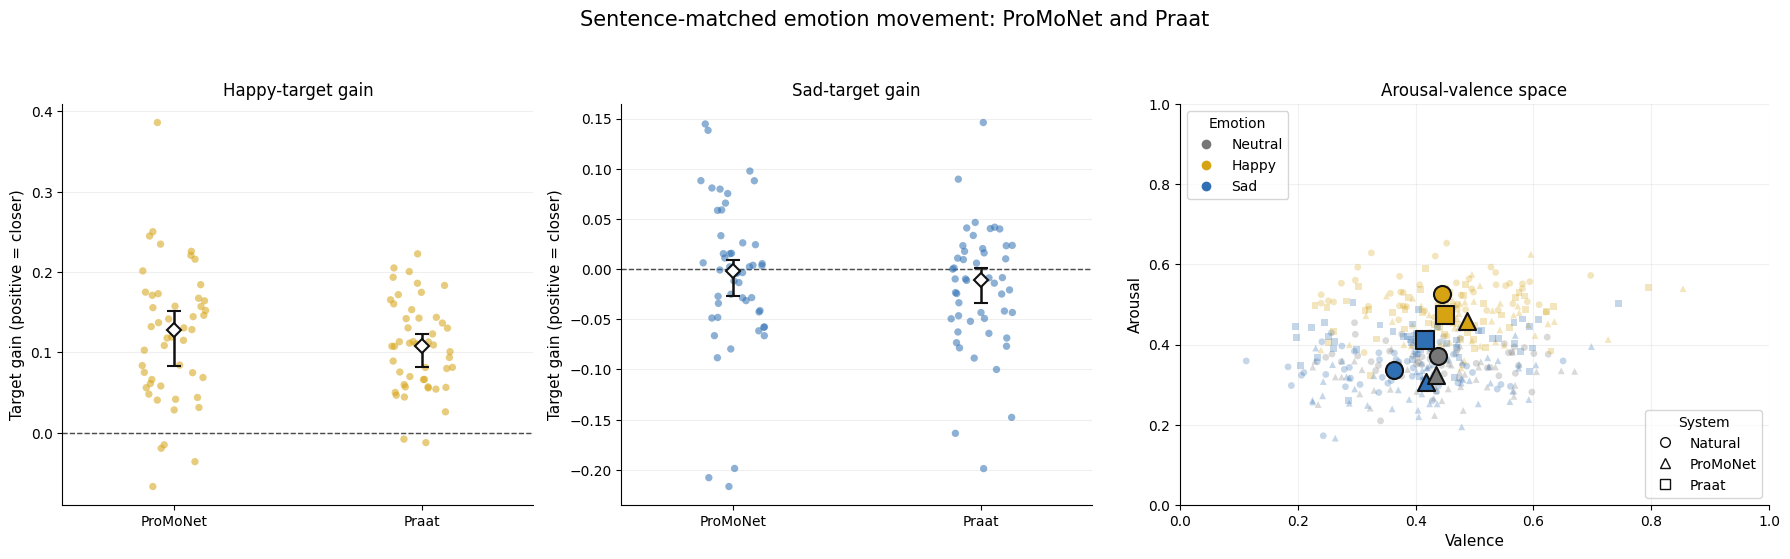

Saved PNG: C:\projects\ProMoNet\outputs\audEERING\emotion_validation_figure.png
Saved PDF: C:\projects\ProMoNet\outputs\audEERING\emotion_validation_figure.pdf


In [5]:
EMOTION_COLORS = {"neu": "#777777", "hap": "#D6A313", "sad": "#2F6FB3"}
SYSTEM_MARKERS = {"natural": "o", "promonet": "^", "praat": "s"}
SYSTEM_LABELS = {"natural": "Natural", "promonet": "ProMoNet", "praat": "Praat"}
TARGET_LABELS = {"hap": "Happy", "sad": "Sad"}

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
fig, axes = plt.subplots(
    1, 3, figsize=(18, 5.6), gridspec_kw={"width_ratios": [1.0, 1.0, 1.25]}
)

def plot_gain_panel(ax: plt.Axes, target_emotion: str, seed_offset: int) -> None:
    for x_position, system in enumerate(["promonet", "praat"]):
        group = per_item[
            per_item["system"].eq(system)
            & per_item["target_emotion"].eq(target_emotion)
        ]
        jitter_rng = np.random.default_rng(RANDOM_SEED + seed_offset + x_position)
        jitter = jitter_rng.uniform(-0.13, 0.13, size=len(group))
        ax.scatter(
            np.full(len(group), x_position, dtype=float) + jitter,
            group["target_gain"],
            s=28, alpha=0.55, color=EMOTION_COLORS[target_emotion],
            edgecolors="none", zorder=2,
        )
        summary_row = summary[
            summary["system"].eq(system)
            & summary["target_emotion"].eq(target_emotion)
        ].iloc[0]
        median = summary_row["median_target_gain"]
        lower = median - summary_row["bootstrap_ci_low"]
        upper = summary_row["bootstrap_ci_high"] - median
        ax.errorbar(
            x_position, median, yerr=np.array([[lower], [upper]]),
            fmt="D", markersize=7, color="#111111", ecolor="#111111",
            capsize=5, elinewidth=1.8, markerfacecolor="white",
            markeredgewidth=1.5, zorder=4,
        )
    ax.axhline(0.0, color="#333333", linestyle="--", linewidth=1.0, zorder=1)
    ax.set_xticks([0, 1], ["ProMoNet", "Praat"])
    ax.set_xlim(-0.45, 1.45)
    ax.set_ylabel("Target gain (positive = closer)")
    ax.set_title(f"{TARGET_LABELS[target_emotion]}-target gain")
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plot_gain_panel(axes[0], "hap", seed_offset=0)
plot_gain_panel(axes[1], "sad", seed_offset=100)

emotion_ax = axes[2]
for system in ["natural", "promonet", "praat"]:
    for emotion in ["neu", "hap", "sad"]:
        group = scores[
            scores["system"].eq(system)
            & scores["target_emotion"].eq(emotion)
        ]
        if group.empty:
            continue
        emotion_ax.scatter(
            group["valence"], group["arousal"],
            marker=SYSTEM_MARKERS[system], color=EMOTION_COLORS[emotion],
            s=24, alpha=0.28, edgecolors="none", zorder=2,
        )

centroids = scores.groupby(
    ["system", "condition", "target_emotion"], as_index=False
)[ADV_COLUMNS].mean()
for centroid in centroids.itertuples(index=False):
    emotion_ax.scatter(
        centroid.valence, centroid.arousal,
        marker=SYSTEM_MARKERS[centroid.system],
        color=EMOTION_COLORS[centroid.target_emotion],
        s=150, alpha=1.0, edgecolors="#111111", linewidths=1.5, zorder=5,
    )
emotion_ax.set_xlim(0.0, 1.0)
emotion_ax.set_ylim(0.0, 1.0)
emotion_ax.set_xlabel("Valence")
emotion_ax.set_ylabel("Arousal")
emotion_ax.set_title("Arousal-valence space")
emotion_ax.grid(alpha=0.18)
emotion_ax.spines[["top", "right"]].set_visible(False)

emotion_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=7,
           markerfacecolor=EMOTION_COLORS[key], markeredgecolor="none", label=label)
    for key, label in [("neu", "Neutral"), ("hap", "Happy"), ("sad", "Sad")]
]
system_handles = [
    Line2D([0], [0], marker=SYSTEM_MARKERS[key], linestyle="none", markersize=7,
           markerfacecolor="white", markeredgecolor="#111111", label=SYSTEM_LABELS[key])
    for key in ["natural", "promonet", "praat"]
]
legend_emotion = emotion_ax.legend(
    handles=emotion_handles, title="Emotion", loc="upper left", frameon=True
)
emotion_ax.add_artist(legend_emotion)
emotion_ax.legend(
    handles=system_handles, title="System", loc="lower right", frameon=True
)

fig.suptitle("Sentence-matched emotion movement: ProMoNet and Praat", fontsize=15, y=0.99)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
fig.savefig(FIGURE_PNG_PATH, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(FIGURE_PDF_PATH, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved PNG: {FIGURE_PNG_PATH}")
print(f"Saved PDF: {FIGURE_PDF_PATH}")

## 5. Paired pipeline t-tests

The website continues to show medians as descriptive summaries. These two-sided paired t-tests answer a different question: whether the mean sentence-level target gain differs between ProMoNet and Praat after pairing the same speaker, sentence, and target emotion.

In [6]:
from scipy.stats import ttest_rel

TTEST_PATH = OUTPUT_DIR / "emotion_gain_paired_ttests.csv"
paired = per_item.pivot(
    index=["speaker_id", "sentence_id", "target_emotion"],
    columns="system",
    values="target_gain",
).reset_index()
if paired[["promonet", "praat"]].isna().any().any():
    raise ValueError("Every paired t-test row must contain both pipeline gains")

ttest_rows = []
for target_code, target_label, expected_n in [("hap", "happy", 49), ("sad", "sad", 50)]:
    group = paired[paired["target_emotion"].eq(target_code)].copy()
    if len(group) != expected_n:
        raise AssertionError(
            f"Expected {expected_n} {target_label} pairs; found {len(group)}"
        )
    statistic, p_value = ttest_rel(
        group["promonet"], group["praat"], alternative="two-sided"
    )
    differences = group["promonet"] - group["praat"]
    ttest_rows.append(
        {
            "target_emotion": target_label,
            "n_pairs": expected_n,
            "promonet_median_target_gain": float(group["promonet"].median()),
            "praat_median_target_gain": float(group["praat"].median()),
            "promonet_mean_target_gain": float(group["promonet"].mean()),
            "praat_mean_target_gain": float(group["praat"].mean()),
            "paired_mean_difference_promonet_minus_praat": float(differences.mean()),
            "t_statistic": float(statistic),
            "degrees_of_freedom": expected_n - 1,
            "p_value_two_sided": float(p_value),
        }
    )

ttest_results = pd.DataFrame(ttest_rows)
write_csv_atomic(ttest_results, TTEST_PATH)
display(ttest_results.style.format({
    "promonet_median_target_gain": "{:.4f}",
    "praat_median_target_gain": "{:.4f}",
    "promonet_mean_target_gain": "{:.4f}",
    "praat_mean_target_gain": "{:.4f}",
    "paired_mean_difference_promonet_minus_praat": "{:.4f}",
    "t_statistic": "{:.3f}",
    "p_value_two_sided": "{:.4f}",
}))

for axis, emotion in zip(axes[:2], ["happy", "sad"]):
    row = ttest_results[ttest_results["target_emotion"].eq(emotion)].iloc[0]
    axis.text(
        0.5, 0.98,
        f"Paired t({int(row['degrees_of_freedom'])}) = {row['t_statistic']:.2f}, "
        f"p = {row['p_value_two_sided']:.3f}",
        transform=axis.transAxes, ha="center", va="top", fontsize=9,
        bbox={"boxstyle": "round,pad=0.28", "facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
    )
fig.savefig(FIGURE_PNG_PATH, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(FIGURE_PDF_PATH, bbox_inches="tight", facecolor="white")
print(f"Saved paired tests to {TTEST_PATH}")
print("Updated the target-gain panels with paired-test annotations.")

,target_emotion,n_pairs,promonet_median_target_gain,praat_median_target_gain,promonet_mean_target_gain,praat_mean_target_gain,paired_mean_difference_promonet_minus_praat,t_statistic,degrees_of_freedom,p_value_two_sided
0,happy,49,0.1283,0.1077,0.1201,0.1071,0.0130,1.273,48,0.2091
1,sad,50,-0.0022,-0.0105,-0.0071,-0.0201,0.0130,0.896,49,0.3747


Saved paired tests to C:\projects\ProMoNet\outputs\audEERING\emotion_gain_paired_ttests.csv
Updated the target-gain panels with paired-test annotations.


## 6. Original-only arousal-valence plot

This figure contains only the 150 natural recordings. The ellipses are 50% covariance **data ellipses** for each observed emotion group, not confidence intervals for the centroid.

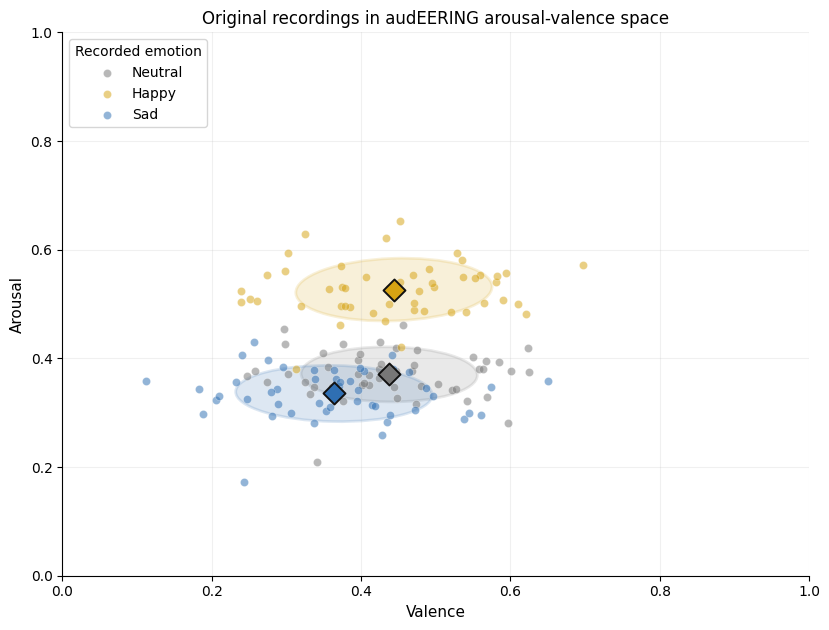

Saved original-only PNG: C:\projects\ProMoNet\outputs\audEERING\original_arousal_valence_space.png
Saved original-only PDF: C:\projects\ProMoNet\outputs\audEERING\original_arousal_valence_space.pdf


In [7]:
from matplotlib.patches import Ellipse
import shutil

ORIGINAL_FIGURE_PNG_PATH = OUTPUT_DIR / "original_arousal_valence_space.png"
ORIGINAL_FIGURE_PDF_PATH = OUTPUT_DIR / "original_arousal_valence_space.pdf"
DOCS_ORIGINAL_FIGURE_PATH = PROJECT_ROOT / "docs" / "images" / "original_arousal_valence_space.png"

original = scores[scores["system"].eq("natural")].copy()
if len(original) != 150:
    raise AssertionError(f"Expected 150 original recordings; found {len(original)}")

def add_data_ellipse_50(ax, x, y, color):
    values = np.column_stack([np.asarray(x, dtype=float), np.asarray(y, dtype=float)])
    center = values.mean(axis=0)
    covariance = np.cov(values, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    # chi-square quantile for probability 0.50 with 2 degrees of freedom
    radius_squared = 2.0 * np.log(2.0)
    width, height = 2.0 * np.sqrt(eigenvalues * radius_squared)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        center, width=width, height=height, angle=angle,
        facecolor=color, edgecolor=color, alpha=0.16, linewidth=2.0, zorder=1,
    )
    ax.add_patch(ellipse)
    return center

fig_original, ax_original = plt.subplots(figsize=(8.4, 6.4))
for emotion in ["neu", "hap", "sad"]:
    group = original[original["target_emotion"].eq(emotion)]
    if len(group) != 50:
        raise AssertionError(f"Expected 50 {emotion} originals; found {len(group)}")
    ax_original.scatter(
        group["valence"], group["arousal"], s=34, alpha=0.52,
        color=EMOTION_COLORS[emotion], edgecolors="white", linewidths=0.35,
        label={"neu": "Neutral", "hap": "Happy", "sad": "Sad"}[emotion], zorder=2,
    )
    center = add_data_ellipse_50(
        ax_original, group["valence"], group["arousal"], EMOTION_COLORS[emotion]
    )
    ax_original.scatter(
        center[0], center[1], marker="D", s=125, color=EMOTION_COLORS[emotion],
        edgecolors="#111111", linewidths=1.4, zorder=4,
    )

ax_original.set_xlim(0.0, 1.0)
ax_original.set_ylim(0.0, 1.0)
ax_original.set_xlabel("Valence")
ax_original.set_ylabel("Arousal")
ax_original.set_title("Original recordings in audEERING arousal-valence space")
ax_original.grid(alpha=0.18)
ax_original.spines[["top", "right"]].set_visible(False)
ax_original.legend(title="Recorded emotion", loc="upper left", frameon=True)
fig_original.tight_layout()
fig_original.savefig(ORIGINAL_FIGURE_PNG_PATH, dpi=300, bbox_inches="tight", facecolor="white")
fig_original.savefig(ORIGINAL_FIGURE_PDF_PATH, bbox_inches="tight", facecolor="white")
shutil.copy2(ORIGINAL_FIGURE_PNG_PATH, DOCS_ORIGINAL_FIGURE_PATH)
plt.show()
print(f"Saved original-only PNG: {ORIGINAL_FIGURE_PNG_PATH}")
print(f"Saved original-only PDF: {ORIGINAL_FIGURE_PDF_PATH}")

## 7. Acceptance checks

Reload the generated tables and verify every requested statistical and figure artifact.

In [8]:
saved_per_item = pd.read_csv(
    PER_ITEM_PATH, dtype={"speaker_id": "string", "sentence_id": "string"}
)
saved_summary = pd.read_csv(SUMMARY_PATH)
saved_ttests = pd.read_csv(TTEST_PATH)
if len(saved_per_item) != 198:
    raise AssertionError(f"Reloaded per-item CSV has {len(saved_per_item)} rows")
if len(saved_summary) != 4:
    raise AssertionError(f"Reloaded summary CSV has {len(saved_summary)} rows")
if saved_ttests["n_pairs"].tolist() != [49, 50]:
    raise AssertionError("Paired t-tests must contain 49 happy and 50 sad pairs")
if not np.isfinite(saved_ttests[["t_statistic", "p_value_two_sided"]].to_numpy()).all():
    raise AssertionError("Paired t-test outputs must be finite")
if len(fig.axes) != 3:
    raise AssertionError(f"Expected three validation panels; found {len(fig.axes)}")
if len(original) != 150 or len(ax_original.patches) != 3:
    raise AssertionError("Original-only plot must contain 150 trials and three ellipses")
for artifact in [
    FIGURE_PNG_PATH, FIGURE_PDF_PATH, TTEST_PATH,
    ORIGINAL_FIGURE_PNG_PATH, ORIGINAL_FIGURE_PDF_PATH, DOCS_ORIGINAL_FIGURE_PATH,
]:
    if not artifact.is_file() or artifact.stat().st_size == 0:
        raise FileNotFoundError(f"Missing or empty artifact: {artifact}")

print("Acceptance checks passed:")
print("  198 sentence-matched edit rows")
print("  4 median/bootstrap summary rows")
print("  2 paired t-tests (49 happy pairs; 50 sad pairs)")
print("  150 original trials with three 50% data ellipses")

Acceptance checks passed:
  198 sentence-matched edit rows
  4 median/bootstrap summary rows
  2 paired t-tests (49 happy pairs; 50 sad pairs)
  150 original trials with three 50% data ellipses
